In [ ]:
import os
import shutil
from google.colab import drive


drive.mount('/content/drive')


data_src = '/content/drive/MyDrive/data'
data_dst = '/content/data'
model_src_dir = '/content/drive/MyDrive/carla_models'
models_to_copy = [
    'has_pedestrian_best.pth',
    'has_vehicle_best.pth',
    'has_traffic_light_best.pth'
]


if os.path.exists(data_src):
    print(f"Copying data from {data_src}...")
    shutil.copytree(data_src, data_dst, dirs_exist_ok=True)
else:
    print(f"Source data path not found: {data_src}")

for model_file in models_to_copy:
    src_path = os.path.join(model_src_dir, model_file)
    dst_path = os.path.join('/content', model_file)
    if os.path.exists(src_path):
        print(f"Copying {model_file}...")
        shutil.copy2(src_path, dst_path)
    else:
        print(f"Model file not found: {src_path}")

print("done")

Mounted at /content/drive
Copying data from /content/drive/MyDrive/data...
Copying has_pedestrian_best.pth...
Copying has_vehicle_best.pth...
Copying has_traffic_light_best.pth...
done


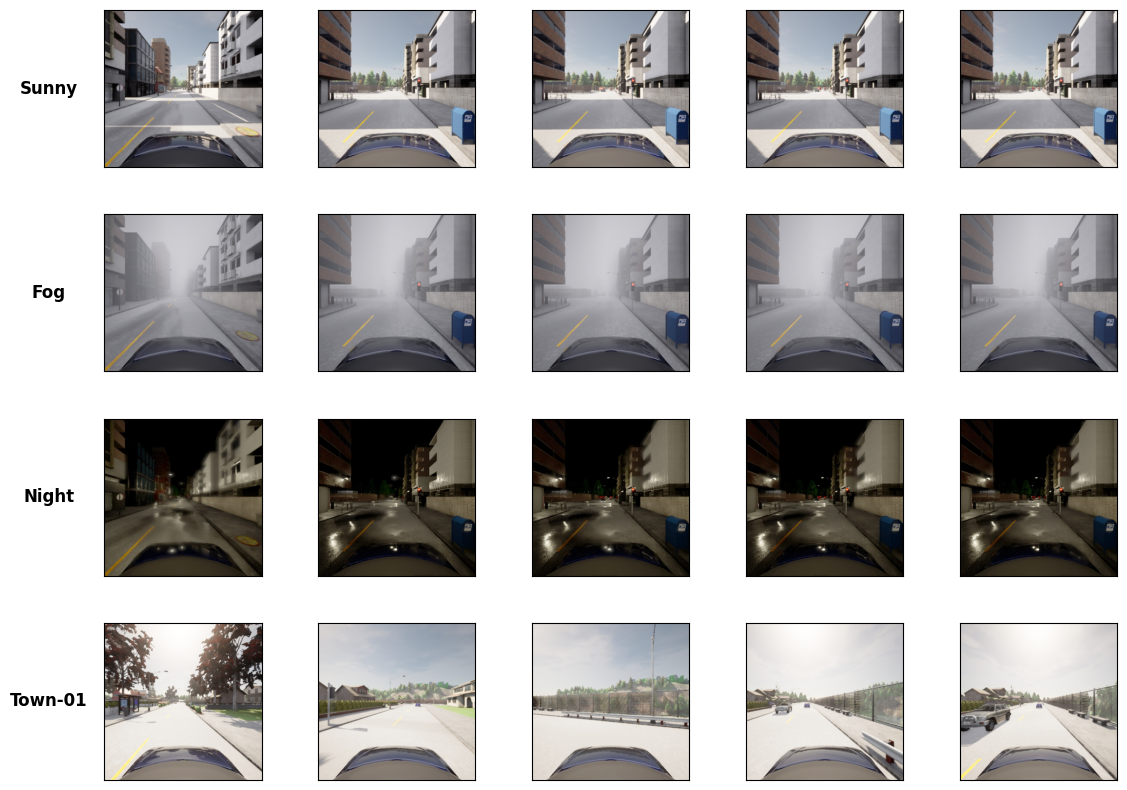

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Configuration
base_path = '/content/data'
categories = {
    'Sunny': 'test',
    'Fog': 'test-fog',
    'Night': 'test-night',
    'Town-01': 'test-town-01'
}

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for row_idx, (label, split_dir) in enumerate(categories.items()):
    split_path = os.path.join(base_path, split_dir)
    csv_path = os.path.join(split_path, 'labels.csv')
    img_dir = os.path.join(split_path, 'rgb-front')

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        sample_frames = df['frame'].head(5).tolist()

        for col_idx, frame in enumerate(sample_frames):
            ax = axes[row_idx, col_idx]


            fname = f"{frame:06d}.jpg"
            img_path = os.path.join(img_dir, fname)

            if os.path.exists(img_path):
                img = Image.open(img_path)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, f'Missing\n{fname}', ha='center', va='center', fontsize=8)

            ax.set_xticks([])
            ax.set_yticks([])

            if col_idx == 0:
                ax.set_ylabel(label, rotation=0, size='large', labelpad=40, fontweight='bold', va='center')
    else:
        for col_idx in range(5):
            axes[row_idx, col_idx].axis('off')
        axes[row_idx, 0].text(0.5, 0.5, f"{label} split not found", ha='center')

plt.subplots_adjust(left=0.2, wspace=0.1, hspace=0.3)
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def load_binary_resnet18(checkpoint_path, device):
    # Initialize ResNet-18
    model = models.resnet18(weights=None)
    # Replace final FC layer (binary classification: output size 1)
    model.fc = nn.Linear(512, 1)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Extract the state dict from the 'model_state_dict' key
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ped_model = load_binary_resnet18('/content/has_pedestrian_best.pth', device)
veh_model = load_binary_resnet18('/content/has_vehicle_best.pth', device)
tl_model = load_binary_resnet18('/content/has_traffic_light_best.pth', device)

print(f"Models loaded successfully on {device}.")

Models loaded successfully on cuda.


In [ ]:
import torch
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CARLADataset(Dataset):
    def __init__(self, split_dir, transform=None):
        self.split_path = os.path.join('/content/data', split_dir)
        self.csv_path = os.path.join(self.split_path, 'labels.csv')
        self.img_dir = os.path.join(self.split_path, 'rgb-front')
        self.df = pd.read_csv(self.csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        frame = self.df.iloc[idx]['frame']
        img_name = f"{frame:06d}.jpg"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_mean_confidence(model, dataloader, device):
    total_confidence = 0.0
    total_samples = 0
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            outputs = model(images)
            probabilities = torch.sigmoid(outputs)
            total_confidence += probabilities.sum().item()
            total_samples += images.size(0)
    return total_confidence / total_samples

splits = {
    'sunny': 'test',
    'fog': 'test-fog',
    'night': 'test-night',
    'town-01': 'test-town-01'
}

models = {
    'pedestrian': ped_model,
    'vehicle': veh_model,
    'traffic_light': tl_model
}

results = {}

for split_name, split_dir in splits.items():
    dataset = CARLADataset(split_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

    results[split_name] = {}
    print(f"Processing split: {split_name}...")

    for model_name, model in models.items():
        mean_conf = get_mean_confidence(model, dataloader, device)
        results[split_name][model_name] = mean_conf

# Display Results Table
results_df = pd.DataFrame(results).transpose()
print("\nMean Confidence Table:")
print(results_df.round(4))

Processing split: sunny...
Processing split: fog...
Processing split: night...
Processing split: town-01...

Mean Confidence Table:
         pedestrian  vehicle  traffic_light
sunny        0.2522   0.6853         0.7385
fog          0.1990   0.6989         0.5140
night        0.2712   0.6644         0.1641
town-01      0.2797   0.7868         0.6947


Exercise 7.6

In [ ]:
import numpy as np
import torch
import torchvision.models as tv_models
from torch.utils.data import DataLoader

def load_tl_model(checkpoint_path, device):
    model = tv_models.resnet18(weights=None)
    model.fc = torch.nn.Linear(512, 1)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

# Load the specific traffic light model
checkpoint_path = '/content/has_traffic_light_best.pth'
travel_model = load_tl_model(checkpoint_path, device)

def get_scores(model, dataloader, device):
    model.eval()
    all_scores = []
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits)
            all_scores.append(probs.cpu().numpy())
    return np.concatenate(all_scores).flatten()

# Mapping splits to directories
split_map = {
    'sunny': 'test',
    'fog': 'test-fog',
    'night': 'test-night',
    'town': 'test-town-01'
}

# Compute scores for each split
loader_args = {'batch_size': 32, 'shuffle': False, 'num_workers': 2}

print("Computing scores...")
scores_sunny = get_scores(travel_model, DataLoader(CARLADataset(split_map['sunny'], transform=transform), **loader_args), device)
scores_fog = get_scores(travel_model, DataLoader(CARLADataset(split_map['fog'], transform=transform), **loader_args), device)
scores_night = get_scores(travel_model, DataLoader(CARLADataset(split_map['night'], transform=transform), **loader_args), device)
scores_town = get_scores(travel_model, DataLoader(CARLADataset(split_map['town'], transform=transform), **loader_args), device)

# Print lengths to confirm
print(f"Scores Sunny: {len(scores_sunny)}")
print(f"Scores Fog: {len(scores_fog)}")
print(f"Scores Night: {len(scores_night)}")
print(f"Scores Town: {len(scores_town)}")

Computing scores...
Scores Sunny: 3600
Scores Fog: 3600
Scores Night: 3600
Scores Town: 3600


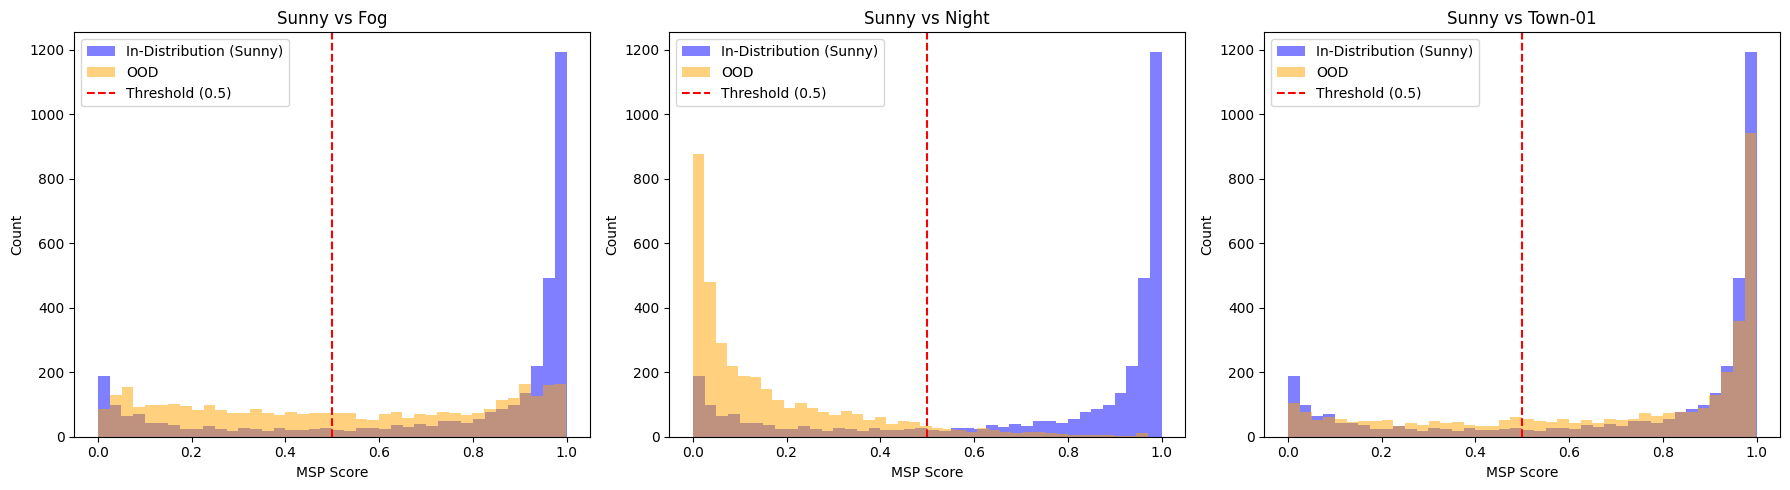

In [ ]:
import matplotlib.pyplot as plt

# Set up the figure with three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data configuration for subplots
ood_splits = [
    (scores_fog, 'Sunny vs Fog'),
    (scores_night, 'Sunny vs Night'),
    (scores_town, 'Sunny vs Town-01')
]

for i, (ood_scores, title) in enumerate(ood_splits):
    ax = axes[i]

    # Plot In-Distribution (Sunny)
    ax.hist(scores_sunny, bins=40, alpha=0.5, color='blue', label='In-Distribution (Sunny)')

    # Plot OOD Split
    ax.hist(ood_scores, bins=40, alpha=0.5, color='orange', label='OOD')

    # Add threshold reference line at 0.5
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.5)')

    # Formatting
    ax.set_title(title)
    ax.set_xlabel('MSP Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('msp_distributions.png')
plt.show()

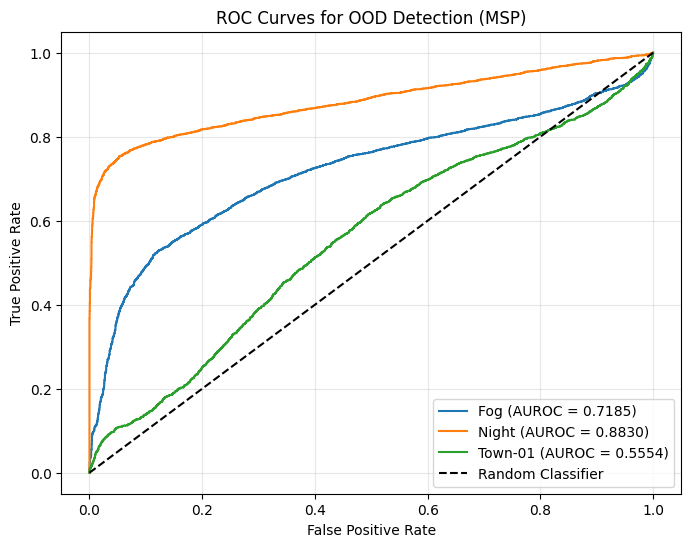


AUROC Summary Table:
Scenario  AUROC
     Fog 0.7185
   Night 0.8830
 Town-01 0.5554


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd

# Configuration
ood_scenarios = [
    (scores_fog, 'Fog'),
    (scores_night, 'Night'),
    (scores_town, 'Town-01')
]

auroc_results = []
plt.figure(figsize=(8, 6))

for ood_scores, label in ood_scenarios:
    y_true = np.concatenate([np.ones(len(scores_sunny)), np.zeros(len(ood_scores))])
    y_scores = np.concatenate([scores_sunny, ood_scores])

    # Compute AUROC
    auroc = roc_auc_score(y_true, y_scores)
    auroc_results.append({'Scenario': label, 'AUROC': round(auroc, 4)})

    # Compute ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'{label} (AUROC = {auroc:.4f})')

# Plot Formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for OOD Detection (MSP)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('msp_roc_curves.png')
plt.show()

# Print Summary Table
auroc_df = pd.DataFrame(auroc_results)
print("\nAUROC Summary Table:")
print(auroc_df.to_string(index=False))

Exercise 7.7


In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader

checkpoint_path = '/content/has_traffic_light_best.pth'
model = load_tl_model(checkpoint_path, device)

features = []
def hook_fn(module, input, output):
    # Flatten the [batch, 512, 1, 1] output to [batch, 512]
    features.append(output.detach().cpu().numpy().reshape(output.size(0), -1))

handle = model.avgpool.register_forward_hook(hook_fn)

def extract_features(model, dataloader, device):
    global features
    features = []
    model.eval()
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            model(images)
    return np.concatenate(features, axis=0)

split_map = {
    'sunny': 'test',
    'fog': 'test-fog',
    'night': 'test-night',
    'town': 'test-town-01'
}

loader_args = {'batch_size': 32, 'shuffle': False, 'num_workers': 2}

print("Extracting features...")
feats_sunny = extract_features(model, DataLoader(CARLADataset(split_map['sunny'], transform=transform), **loader_args), device)
feats_fog = extract_features(model, DataLoader(CARLADataset(split_map['fog'], transform=transform), **loader_args), device)
feats_night = extract_features(model, DataLoader(CARLADataset(split_map['night'], transform=transform), **loader_args), device)
feats_town = extract_features(model, DataLoader(CARLADataset(split_map['town'], transform=transform), **loader_args), device)

handle.remove()

print(f"feats_sunny shape: {feats_sunny.shape}")
print(f"feats_fog shape:   {feats_fog.shape}")
print(f"feats_night shape: {feats_night.shape}")
print(f"feats_town shape:  {feats_town.shape}")

Extracting features...
feats_sunny shape: (3600, 512)
feats_fog shape:   (3600, 512)
feats_night shape: (3600, 512)
feats_town shape:  (3600, 512)


Computing Mahalanobis distances...

Mahalanobis AUROC Results:
Fog: 1.0000
Night: 1.0000
Town-01: 0.9938


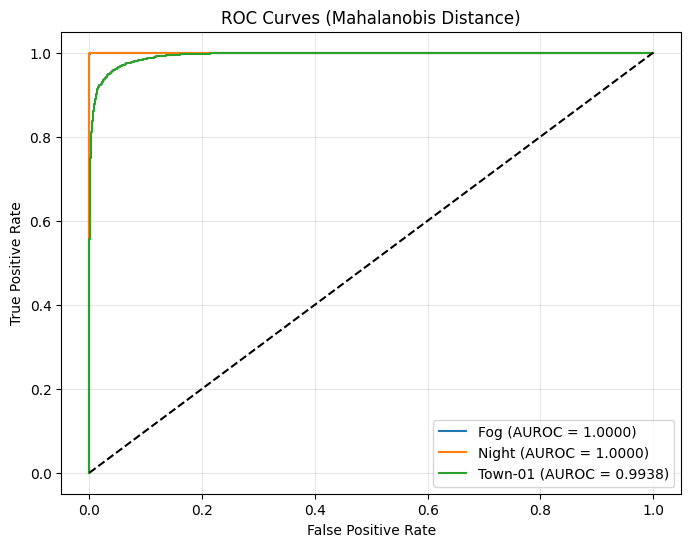

In [ ]:
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

mean_sunny = np.mean(feats_sunny, axis=0)
cov_sunny = np.cov(feats_sunny, rowvar=False)
# Use pseudo-inverse for stability if the covariance matrix is singular
precision_sunny = np.linalg.pinv(cov_sunny)

def compute_mahalanobis_distances(features, mean, precision):
    diff = features - mean
    # Efficiently compute (diff * precision * diff.T) for each row
    distances = np.array([mahalanobis(f, mean, precision) for f in features])
    return distances

print("Computing Mahalanobis distances...")
dist_sunny = compute_mahalanobis_distances(feats_sunny, mean_sunny, precision_sunny)
dist_fog = compute_mahalanobis_distances(feats_fog, mean_sunny, precision_sunny)
dist_night = compute_mahalanobis_distances(feats_night, mean_sunny, precision_sunny)
dist_town = compute_mahalanobis_distances(feats_town, mean_sunny, precision_sunny)

# 2. Evaluate AUROC for Mahalanobis-based OOD detection
scenarios = [
    (dist_fog, 'Fog'),
    (dist_night, 'Night'),
    (dist_town, 'Town-01')
]

plt.figure(figsize=(8, 6))
print("\nMahalanobis AUROC Results:")
for dist_ood, label in scenarios:
    y_true = np.concatenate([np.zeros(len(dist_sunny)), np.ones(len(dist_ood))])
    y_scores = np.concatenate([dist_sunny, dist_ood])

    auroc = roc_auc_score(y_true, y_scores)
    print(f"{label}: {auroc:.4f}")

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'{label} (AUROC = {auroc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Mahalanobis Distance)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

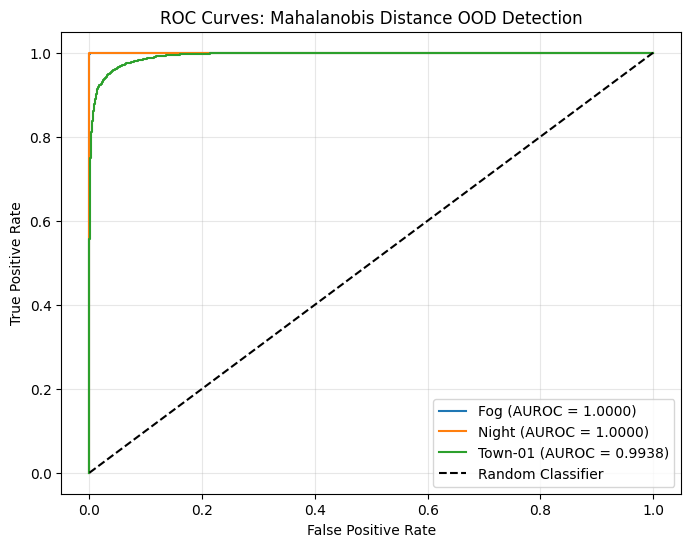


OOD Detection Performance Comparison:
Scenario  MSP AUROC (Baseline)  Mahalanobis AUROC
     Fog                0.7185           0.999996
   Night                0.8830           1.000000
 Town-01                0.5554           0.993778


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd

# Map existing distance variables to the names requested in the prompt
maha_sunny = dist_sunny
maha_fog = dist_fog
maha_night = dist_night
maha_town = dist_town

# MSP Baseline scores provided by user
msp_baseline = {
    'Fog': 0.7185,
    'Night': 0.8830,
    'Town-01': 0.5554
}

scenarios = [
    (maha_fog, 'Fog'),
    (maha_night, 'Night'),
    (maha_town, 'Town-01')
]

mahalanobis_aurocs = {}
plt.figure(figsize=(8, 6))

for maha_ood, label in scenarios:
    # Label convention: in-distribution=0, OOD=1
    # Higher Mahalanobis = more OOD
    y_true = np.concatenate([np.zeros(len(maha_sunny)), np.ones(len(maha_ood))])
    y_scores = np.concatenate([maha_sunny, maha_ood])

    # Compute AUROC
    auroc = roc_auc_score(y_true, y_scores)
    mahalanobis_aurocs[label] = auroc

    # Compute and plot ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'{label} (AUROC = {auroc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Mahalanobis Distance OOD Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('mahalanobis_roc_curves.png')
plt.show()
e
comparison_data = {
    'Scenario': ['Fog', 'Night', 'Town-01'],
    'MSP AUROC (Baseline)': [msp_baseline['Fog'], msp_baseline['Night'], msp_baseline['Town-01']],
    'Mahalanobis AUROC': [mahalanobis_aurocs['Fog'], mahalanobis_aurocs['Night'], mahalanobis_aurocs['Town-01']]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nOOD Detection Performance Comparison:")
print(comparison_df.to_string(index=False))